# 6-dot CMOS + Pad Frame (v1)

本 notebook 依次展示：
1) **器件设计图**（device core）
2) **pad frame**
3) **器件放在 pad frame 中央的 assembly 图**：两张（全图 + 聚焦器件与 pad 引线末端）

说明：
- device 的默认参数已与 `six_dot_generator_SG1_CMOS_20260312.py` 的 `main()` 保持一致（见 `QuantumDotPadGenerator6DotCMOS.generate_quantum_dot_layout()`）。
- pad frame 依然沿用 `Prefab-18-dot/20260109/quantum_dot_pad_generator_18dot_v3.py` 的风格：4 边 pad + 4 级 active region + 多级 inner leads。


In [1]:
import os, sys
import gdstk
import numpy as np
import matplotlib.pyplot as plt

# 让 Python 能 import 当前目录下的 generator
sys.path.append(os.getcwd())

from quantum_dot_pad_generator_6dot_cmos_v1 import QuantumDotPadGenerator6DotCMOS
from six_dot_generator_SG1_CMOS_20260312 import plot_gds

%matplotlib inline


In [2]:
# 输出目录
out_dir = os.path.join(os.getcwd(), "output_6dot")
os.makedirs(out_dir, exist_ok=True)
out_dir


'c:\\Users\\Administrator\\Desktop\\Spin_Quantum_Hardware_Simulation\\GDS_Drawer\\6-dot\\CMOS Proj\\output_6dot'

In [3]:
# 1) 初始化 generator
gen = QuantumDotPadGenerator6DotCMOS()


## 1) 器件设计图（device）

注意：这里 **不传任何参数**，将自动使用与 `six_dot_generator_SG1_CMOS_20260312.py` 的 `main()` 一致的默认参数。


计算中间 S/D 引线延长部分: bend=0.075, extend=0.000
6量子点器件核心已创建:
  - 主阵列量子点: 6 个
  - 传感器阵列量子点: 2 个
  - 总连接点数: 30
device connection points: 30
视图范围: X[-0.79, 1.89], Y[-0.46, 1.40]


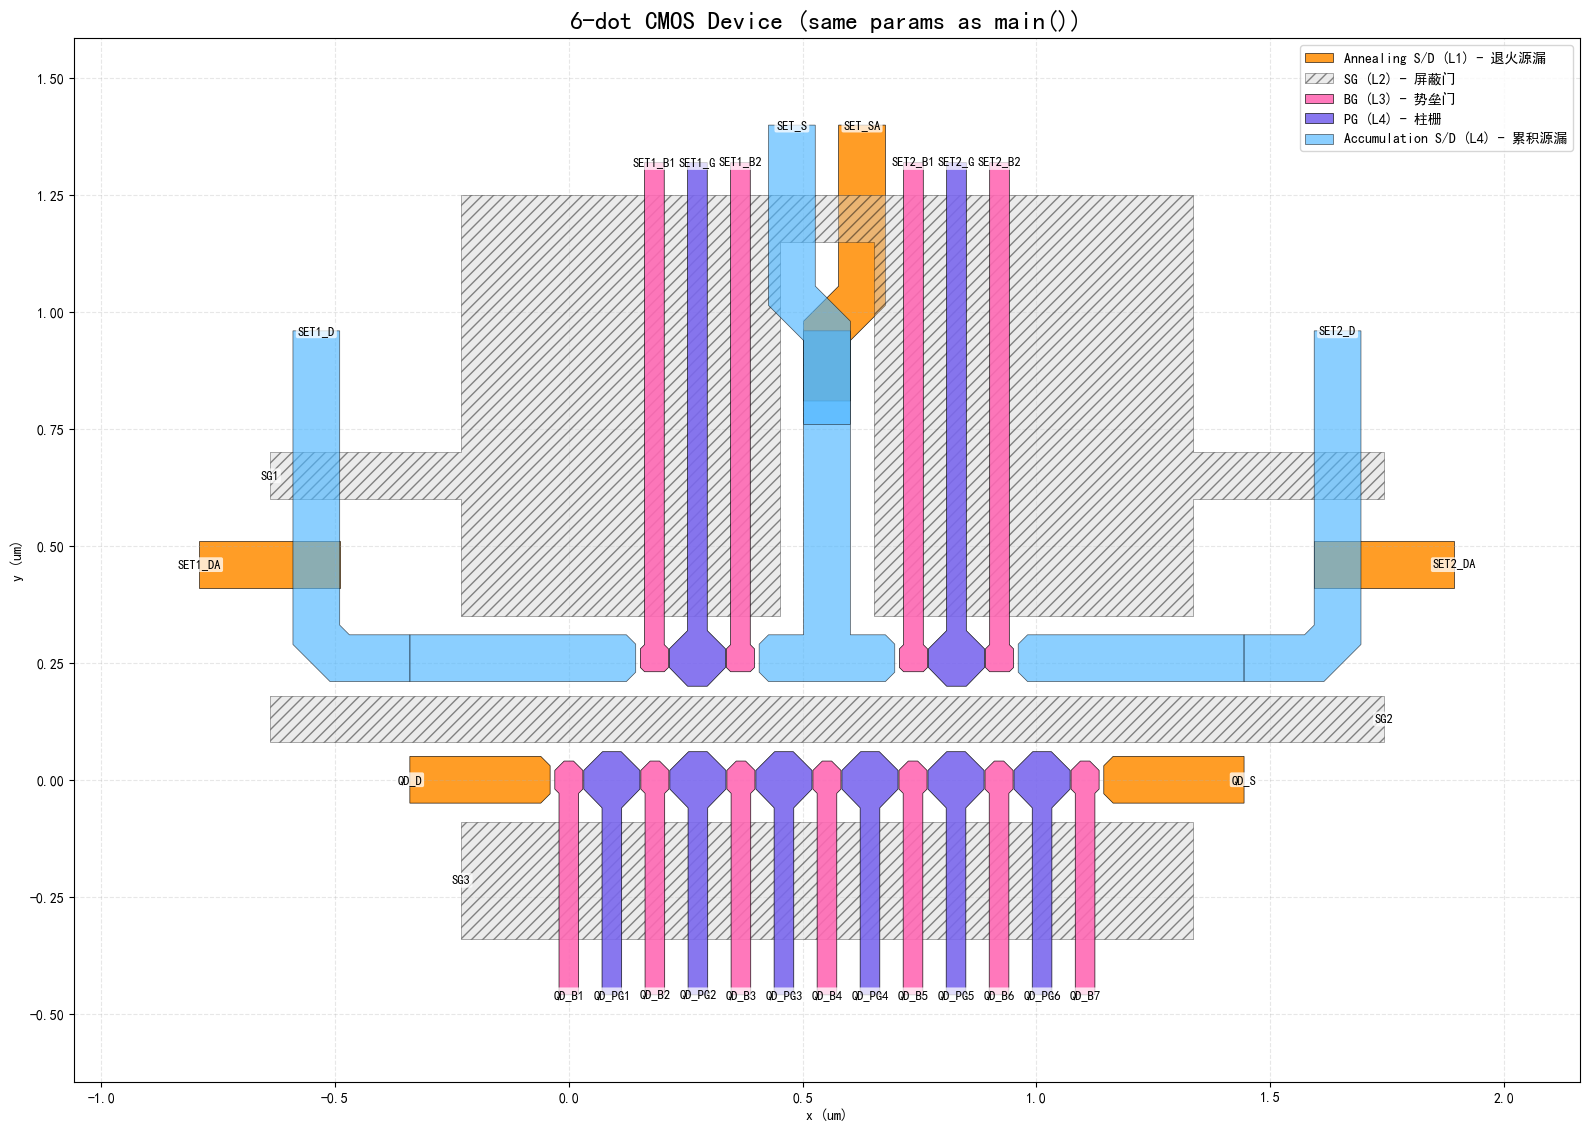

In [4]:
device_lib, device_cell, device_connection_points = gen.generate_quantum_dot_layout()
print("device connection points:", len(device_connection_points))

# 展示器件图
plot_gds(device_cell, title="6-dot CMOS Device (same params as main())")


In [5]:
# 保存 device
device_gds = os.path.join(out_dir, "6dot_cmos_device_v1.gds")
gen.save_gds(device_lib, device_gds)


GDS saved: c:\Users\Administrator\Desktop\Spin_Quantum_Hardware_Simulation\GDS_Drawer\6-dot\CMOS Proj\output_6dot\6dot_cmos_device_v1.gds


## 2) Pad Frame

pad 四边列表（按顺序）。这些 label 会作为 pad 的命名，同时也是 pad frame 的 connection points key。


In [6]:
tp = [
    "SET1_B1", "SET1_G", "SET1_B2", "SET_S", "SET_SA", "SET2_B1", "SET2_G", "SET2_B2"
]

bp = [
    "QD_PG2", "QD_B3", "QD_PG3", "QD_B4", "QD_PG4", "QD_B5", "QD_PG5"
]

lp = [
    "SET1_D", "SG1", "SET1_DA", "QD_D", "SG3", "QD_B1", "QD_PG1", "QD_B2"
]

rp = [
    "SET2_D", "GND", "SET2_DA", "SG2", "QD_S", "QD_B7", "QD_PG6", "QD_B6"
]

print("pad count:", len(tp) + len(bp) + len(lp) + len(rp))


pad count: 31


active_center: (1150.0, 1150.0)
pad_connection_points: 31


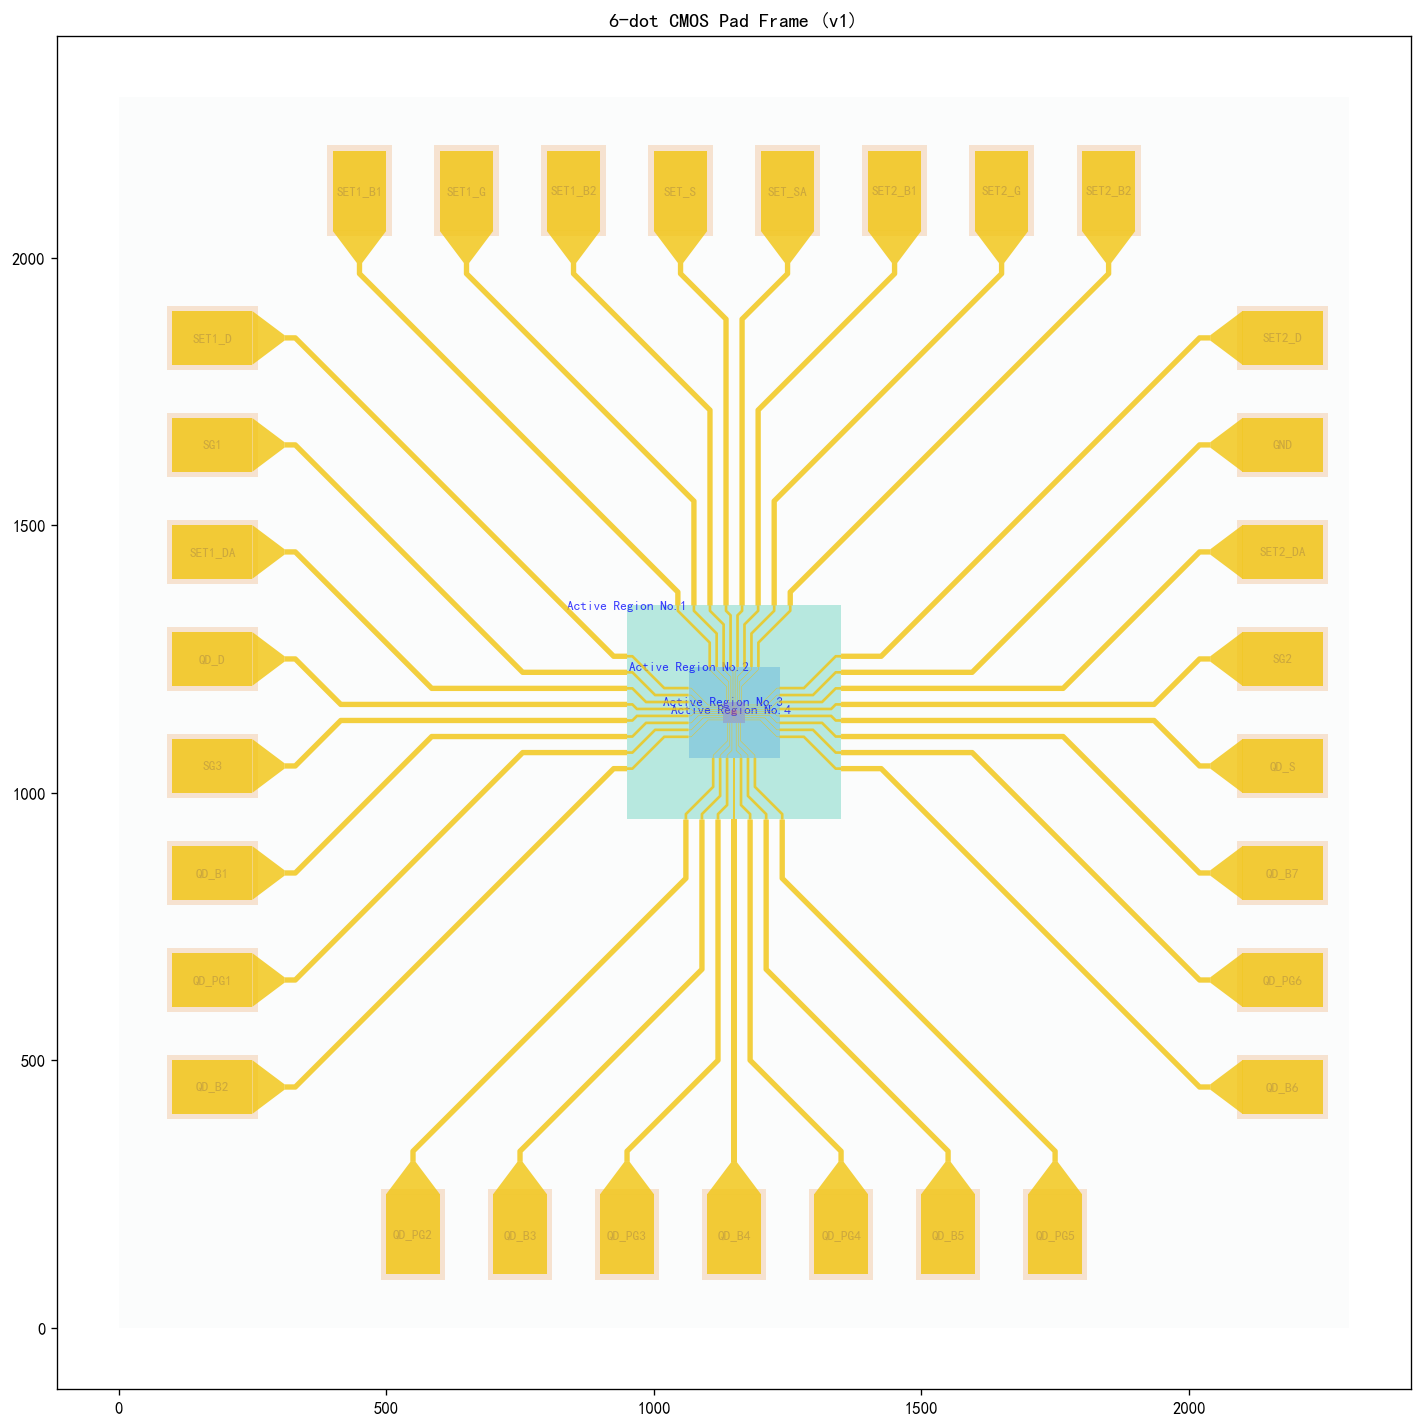

In [7]:
pad_lib, pad_cell, pad_connection_points, active_center, all_pads_info = gen.generate_pad_frame_layout(
    tp=tp,
    bp=bp,
    lp=lp,
    rp=rp,
    # 你可以在这里继续调参数
    layout_width=2300,
    layout_height=2300,

    pad_width= 100,
    pad_height=150,
    pad_spacing=100,

    taper_length=60,
    active_width=400,
    active_height=400,
    trace_width=10,
    trace_spacing=20,
    
    active_size_2=170,
    inner_trace_width=5.0,
    inner_trace_spacing=8.0,
    active_entry_len_2=15,
    
    active_size_3=40,
    inner_trace_width_3=1,
    inner_trace_spacing_3=3,
    active_entry_len_3=8,
    
    active_width_4=10,
    active_height_4=10,
    inner_trace_width_4=0.2,
    inner_trace_spacing_4=0.5,
    active_entry_len_4=1,
)

print("active_center:", active_center)
print("pad_connection_points:", len(pad_connection_points))

# 展示 pad frame
gen.plot_pad_frame(pad_cell, title="6-dot CMOS Pad Frame (v1)", show_plot=True)


In [8]:
# 保存 pad frame
pad_gds = os.path.join(out_dir, "6dot_cmos_pad_frame_v1.gds")
gen.save_gds(pad_lib, pad_gds)


GDS saved: c:\Users\Administrator\Desktop\Spin_Quantum_Hardware_Simulation\GDS_Drawer\6-dot\CMOS Proj\output_6dot\6dot_cmos_pad_frame_v1.gds


## 3) Assembly（device 放入 pad frame 中央）

下面会展示两张：
- 全图
- 聚焦器件 + pad 引线末端（Active4 周围）


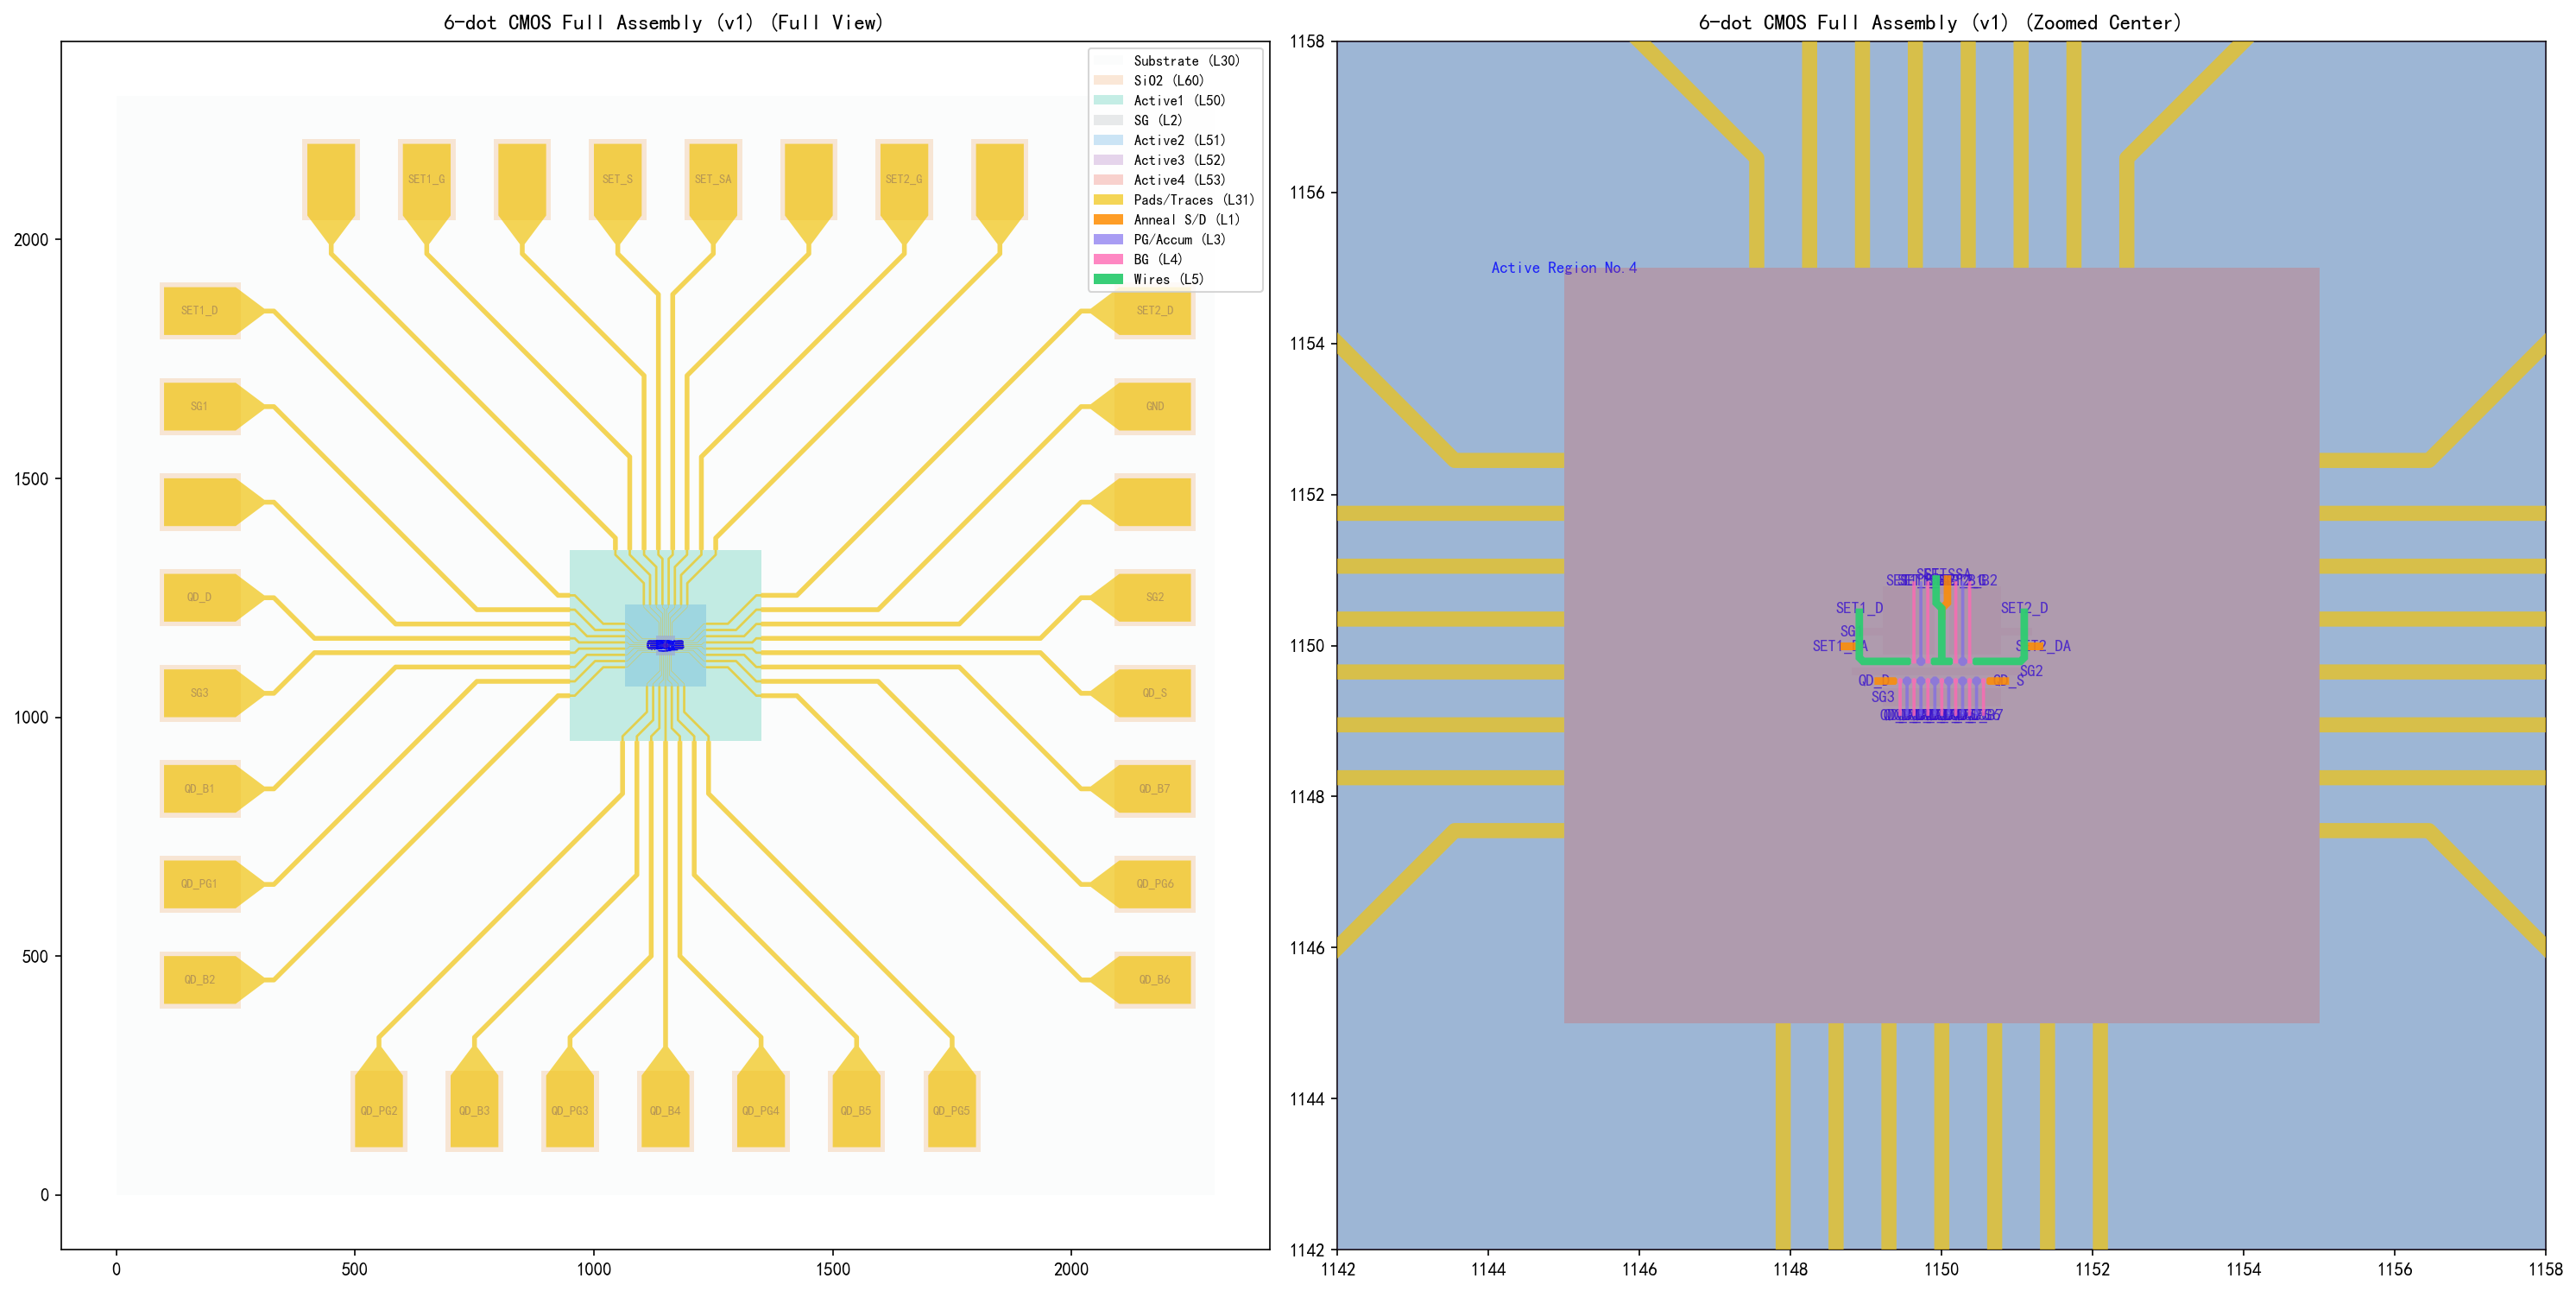

In [9]:
assembly_lib, assembly_cell = gen.assemble_device_and_pad_frame()
assert assembly_lib is not None and assembly_cell is not None

# 展示 assembly：全图 + zoom
gen.plot_assembly(assembly_cell, title="6-dot CMOS Full Assembly (v1)", show_plot=True, zoom_factor=0.02)


In [10]:
# 保存 assembly
assembly_gds = os.path.join(out_dir, "6dot_cmos_full_assembly_v1.gds")
gen.save_gds(assembly_lib, assembly_gds)


GDS saved: c:\Users\Administrator\Desktop\Spin_Quantum_Hardware_Simulation\GDS_Drawer\6-dot\CMOS Proj\output_6dot\6dot_cmos_full_assembly_v1.gds


## 4) Wiring（连接Device和pad lead）

In [11]:
print("Pad Connection Points:", pad_connection_points)
print("Device Connection Points:", device_connection_points)

Pad Connection Points: {'SET1_B1': (np.float64(1147.55), 1155.0), 'SET1_G': (np.float64(1148.25), 1155.0), 'SET1_B2': (np.float64(1148.95), 1155.0), 'SET_S': (np.float64(1149.65), 1155.0), 'SET_SA': (np.float64(1150.35), 1155.0), 'SET2_B1': (np.float64(1151.05), 1155.0), 'SET2_G': (np.float64(1151.75), 1155.0), 'SET2_B2': (np.float64(1152.45), 1155.0), 'QD_PG2': (np.float64(1147.9), 1145.0), 'QD_B3': (np.float64(1148.6), 1145.0), 'QD_PG3': (np.float64(1149.3), 1145.0), 'QD_B4': (np.float64(1150.0), 1145.0), 'QD_PG4': (np.float64(1150.7), 1145.0), 'QD_B5': (np.float64(1151.4), 1145.0), 'QD_PG5': (np.float64(1152.1), 1145.0), 'SET1_D': (1145.0, np.float64(1152.45)), 'SG1': (1145.0, np.float64(1151.75)), 'SET1_DA': (1145.0, np.float64(1151.05)), 'QD_D': (1145.0, np.float64(1150.35)), 'SG3': (1145.0, np.float64(1149.65)), 'QD_B1': (1145.0, np.float64(1148.95)), 'QD_PG1': (1145.0, np.float64(1148.25)), 'QD_B2': (1145.0, np.float64(1147.55)), 'SET2_D': (1155.0, np.float64(1152.45)), 'GND': (

In [12]:
LAYER_SD_ANNEAL = 1      # Annealing Source/Drain - 退火源漏层（橙色）
LAYER_SG = 2             # Screen Gate - 屏蔽门层
LAYER_PG_BG_ACC = 5      # Plunger Gate, barrier gate, accumulation gate - 柱栅层、势垒门层、累积层

Connecting bottom pad leads...
Connecting left pad leads...
Connecting right pad leads...
Connecting top SET pad leads...


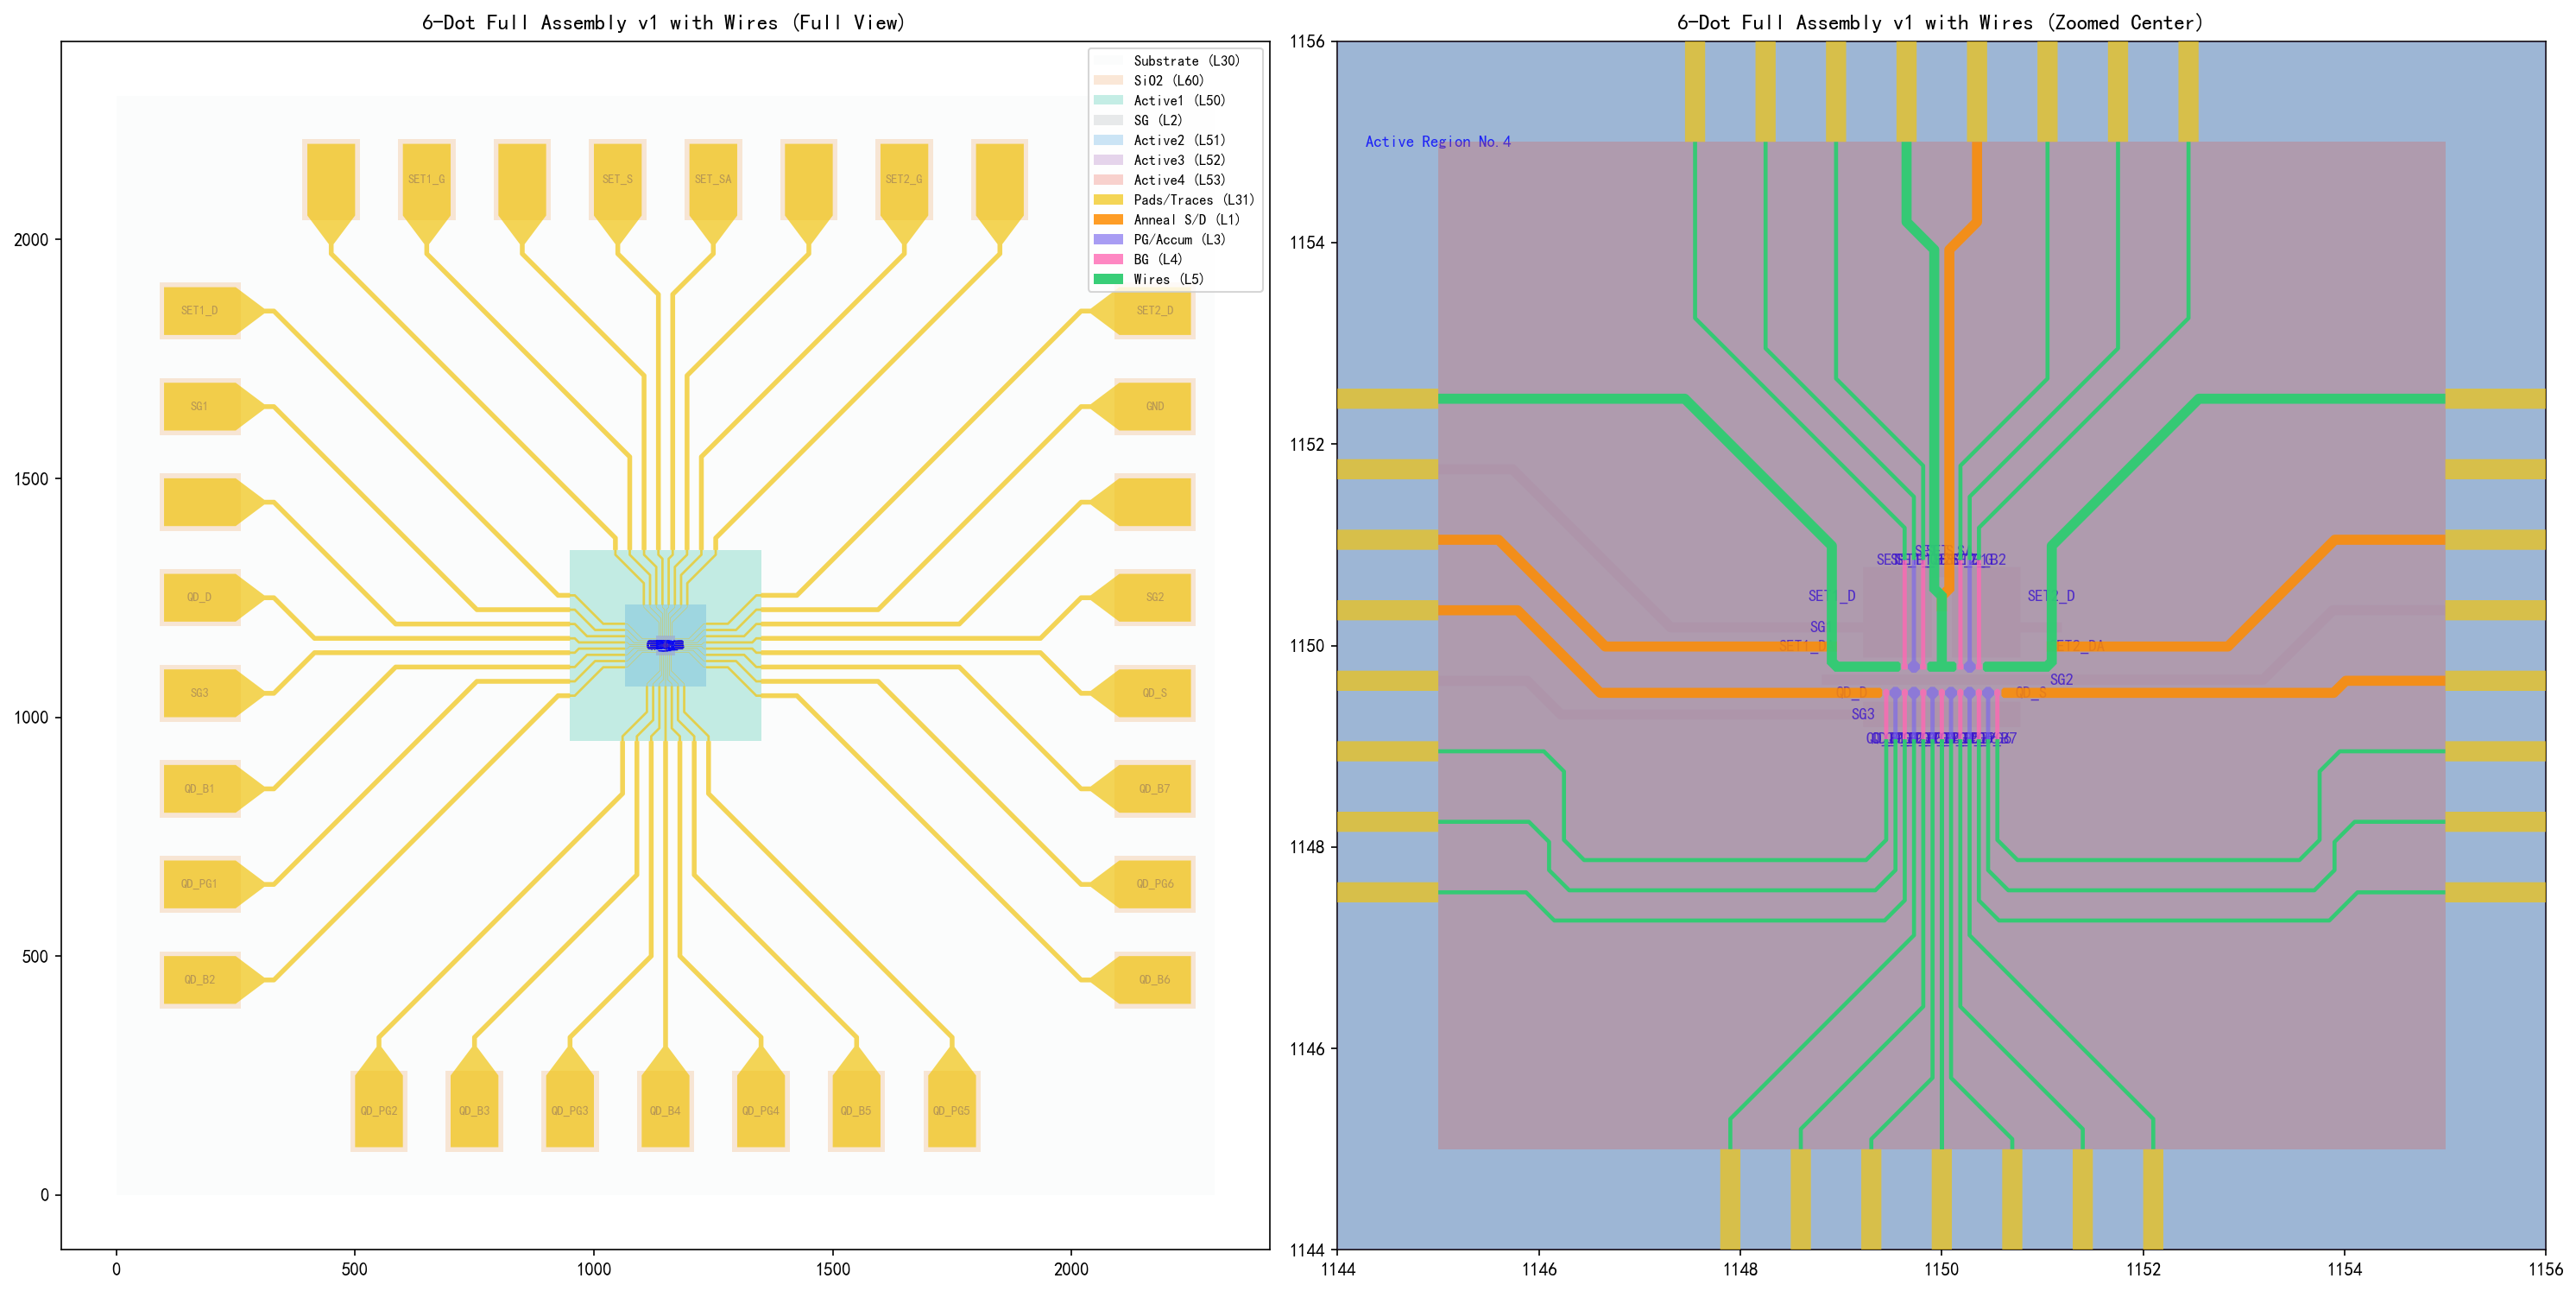


Successfully assembled, wired
GDS saved: c:\Users\Administrator\Desktop\Spin_Quantum_Hardware_Simulation\GDS_Drawer\6-dot\CMOS Proj\output_6dot\6dot_cmos_full_assembly_v1_wired.gds


In [18]:
# 5. Add connection wires one by one (40nm width)
assembly_lib2, assembly_cell2 = gen.assemble_device_and_pad_frame()

if assembly_cell2 is not None:
    import pandas as pd
    from IPython.display import display

    # Calculate translation for device points
    bbox = device_cell.bounding_box()
    dev_cx, dev_cy = (bbox[0][0] + bbox[1][0]) / 2, (bbox[0][1] + bbox[1][1]) / 2
    tx, ty = active_center[0] - dev_cx, active_center[1] - dev_cy

    # # connect QD_B4
    # p_pad = pad_connection_points.get("QD_B4")
    # p_dev = (device_connection_points.get("QD_B4")[0] + tx, device_connection_points.get("QD_B4")[1] + ty)
    # path_pts = [p_pad, p_dev]
    # wire = gen.create_gds_wire(path_pts, width=0.040)
    # assembly_cell2.add(wire)

    # connect bottom pads
    bottom_labels = bp
    print("Connecting bottom pad leads...")
    for i, label in enumerate(bottom_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            if label == "QD_B4":
                path_pts = [p_pad, p_dev]
            else:
                dist_from_center = abs(i - 3)
                entry_length = 0.1 * dist_from_center

                delta_x = p_dev[0] - p_pad[0]
                p_turn_pad = (p_pad[0], p_pad[1] + entry_length)
                p_turn_dev = (p_dev[0], p_pad[1] + entry_length + abs(delta_x))
                path_pts = [p_pad, p_turn_pad, p_turn_dev, p_dev]
            wire = gen.create_gds_wire(path_pts, width=0.040)
            assembly_cell2.add(wire)

    # connect left pads
    QD_left_labels = ["QD_B1", "QD_PG1", "QD_B2"]
    print("Connecting left pad leads...")
    for i, label in enumerate(QD_left_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            delta_y = p_pad[1] - p_dev[1]
            dev_entry = 1 + 0.3 * abs(i)
            bend = 0.2
            extend = 0.24 * abs(i) + 3
            # pt1 = (p_dev[0], p_dev[1] - dev_entry)
            # pt2 = (p_dev[0] - bend, p_dev[1] - dev_entry - bend)
            # pt3 = (p_dev[0] - extend, p_dev[1] - dev_entry - bend)
            # pt4 = (p_dev[0] - extend - bend, p_dev[1] - dev_entry)
            # pt5 = (p_dev[0] - extend - bend, p_dev[1] + delta_y - bend)
            # pt6 = (p_dev[0] - extend - bend * 2, p_dev[1] + delta_y)

            delta1 = p_pad[1] - (p_dev[1] - dev_entry - bend)
            if delta_y - bend < - dev_entry and delta1 > 0:
                pt3 = (p_dev[0] - extend - abs(delta1), p_dev[1] - dev_entry - bend + delta1)
                pt4 = (p_dev[0] - extend, p_dev[1] - dev_entry - bend)
                pt5 = (p_dev[0] - bend, p_dev[1] - dev_entry - bend)
                pt6 = (p_dev[0], p_dev[1] - dev_entry)
                path_pts = [p_pad, pt3, pt4, pt5, pt6, p_dev]
                wire = gen.create_gds_wire(path_pts, width=0.040)
            elif delta_y - bend < - dev_entry and delta1 <= 0:
                pt3 = (p_dev[0] - extend - abs(delta1), p_dev[1] - dev_entry - bend + delta1)
                pt4 = (p_dev[0] - extend, p_dev[1] - dev_entry - bend)
                pt5 = (p_dev[0] - bend, p_dev[1] - dev_entry - bend)
                pt6 = (p_dev[0], p_dev[1] - dev_entry)
                path_pts = [p_pad, pt3, pt4, pt5, pt6, p_dev]
                wire = gen.create_gds_wire(path_pts, width=0.040)
            else:
                pt1 = (p_dev[0] - extend - bend * 2, p_dev[1] + delta_y)
                pt2 = (p_dev[0] - extend - bend, p_dev[1] + delta_y - bend)
                pt3 = (p_dev[0] - extend - bend, p_dev[1] - dev_entry)
                pt4 = (p_dev[0] - extend, p_dev[1] - dev_entry - bend)
                pt5 = (p_dev[0] - bend, p_dev[1] - dev_entry - bend)
                pt6 = (p_dev[0], p_dev[1] - dev_entry)
                path_pts = [p_pad, pt1, pt2, pt3, pt4, pt5, pt6, p_dev]
                wire = gen.create_gds_wire(path_pts, width=0.040)
            
            assembly_cell2.add(wire)

    # connect left SG3
    p_pad = pad_connection_points.get("SG3")
    p_dev = (device_connection_points.get("SG3")[0] + tx, device_connection_points.get("SG3")[1] + ty)
    extend_x_SG3 = 3
    delta_y_SG3 = p_pad[1] - p_dev[1]
    pt1 = (p_dev[0] - extend_x_SG3, p_dev[1])
    pt2 = (p_dev[0] - extend_x_SG3 - delta_y_SG3, p_pad[1])
    path_pts = [p_pad, pt2, pt1, p_dev]
    wire = gen.create_gds_wire(path_pts, width=0.10, layer=LAYER_SG)
    assembly_cell2.add(wire)

    # connect left QD_D
    p_pad = pad_connection_points.get("QD_D")
    p_dev = (device_connection_points.get("QD_D")[0] + tx, device_connection_points.get("QD_D")[1] + ty)
    extend_x_QD_D = 2.5
    delta_y_QD_D = p_pad[1] - p_dev[1]
    pt1 = (p_dev[0] - extend_x_QD_D, p_dev[1])
    pt2 = (p_dev[0] - extend_x_QD_D - delta_y_QD_D, p_pad[1])
    path_pts = [p_pad, pt2, pt1, p_dev]
    wire = gen.create_gds_wire(path_pts, width=0.10, layer=LAYER_SD_ANNEAL)
    assembly_cell2.add(wire)

    # connect left SET1_DA
    p_pad = pad_connection_points.get("SET1_DA")
    p_dev = (device_connection_points.get("SET1_DA")[0] + tx, device_connection_points.get("SET1_DA")[1] + ty)
    extend_x_SET1_DA = 2
    delta_y_SET1_DA = p_pad[1] - p_dev[1]
    pt1 = (p_dev[0] - extend_x_SET1_DA, p_dev[1])
    pt2 = (p_dev[0] - extend_x_SET1_DA - delta_y_SET1_DA, p_pad[1])
    path_pts = [p_pad, pt2, pt1, p_dev]
    wire = gen.create_gds_wire(path_pts, width=0.10, layer=LAYER_SD_ANNEAL)
    assembly_cell2.add(wire)

    # connect left SG1
    p_pad = pad_connection_points.get("SG1")
    p_dev = (device_connection_points.get("SG1")[0] + tx, device_connection_points.get("SG1")[1] + ty)
    extend_x_SG1 = 1.5
    delta_SG1= p_pad[1] - p_dev[1]
    pt1 = (p_dev[0] - extend_x_SG1, p_dev[1])
    pt2 = (p_dev[0] - extend_x_SG1 - delta_SG1, p_pad[1])
    path_pts = [p_pad, pt2, pt1, p_dev]
    wire = gen.create_gds_wire(path_pts, width=0.10, layer=LAYER_SG)
    assembly_cell2.add(wire)
    
    # connect left SET1_D
    p_pad = pad_connection_points.get("SET1_D")
    p_dev = (device_connection_points.get("SET1_D")[0] + tx, device_connection_points.get("SET1_D")[1] + ty)
    extend_y_SET1_D = 0.5
    delta_y_SET1_D = p_pad[1] - p_dev[1]
    pt1 = (p_dev[0], p_dev[1] + extend_y_SET1_D)
    pt2 = (p_dev[0] - (delta_y_SET1_D - extend_y_SET1_D), p_pad[1])
    path_pts = [p_pad, pt2, pt1, p_dev]
    wire = gen.create_gds_wire(path_pts, width=0.10, layer=LAYER_PG_BG_ACC)
    assembly_cell2.add(wire)

    # connect right pads
    # rp = ["SET2_D", "GND", "SET2_DA", "SG2", "QD_S", "QD_B7", "QD_PG6", "QD_B6"]
    QD_right_labels = ["QD_B6", "QD_PG6", "QD_B7"]
    print("Connecting right pad leads...")
    for i, label in enumerate(QD_right_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            delta_y = p_pad[1] - p_dev[1]
            dev_entry = 1 + 0.3 * abs(2-i)
            bend = 0.2
            extend = 0.24 * abs(2-i) + 3

            delta1 = p_pad[1] - (p_dev[1] - dev_entry - bend)
            if delta_y - bend < - dev_entry and delta1 > 0:
                pt3 = (p_dev[0] + extend + abs(delta1), p_dev[1] - dev_entry - bend + delta1)
                pt4 = (p_dev[0] + extend, p_dev[1] - dev_entry - bend)
                pt5 = (p_dev[0] + bend, p_dev[1] - dev_entry - bend)
                pt6 = (p_dev[0], p_dev[1] - dev_entry)
                path_pts = [p_pad, pt3, pt4, pt5, pt6, p_dev]
                wire = gen.create_gds_wire(path_pts, width=0.040)
            elif delta_y - bend < - dev_entry and delta1 <= 0:
                pt3 = (p_dev[0] + extend + abs(delta1), p_dev[1] - dev_entry - bend + delta1)
                pt4 = (p_dev[0] + extend, p_dev[1] - dev_entry - bend)
                pt5 = (p_dev[0] + bend, p_dev[1] - dev_entry - bend)
                pt6 = (p_dev[0], p_dev[1] - dev_entry)
                path_pts = [p_pad, pt3, pt4, pt5, pt6, p_dev]
                wire = gen.create_gds_wire(path_pts, width=0.040)
            else:
                pt1 = (p_dev[0] + extend + bend * 2, p_dev[1] + delta_y)
                pt2 = (p_dev[0] + extend + bend, p_dev[1] + delta_y - bend)
                pt3 = (p_dev[0] + extend + bend, p_dev[1] - dev_entry)
                pt4 = (p_dev[0] + extend, p_dev[1] - dev_entry - bend)
                pt5 = (p_dev[0] + bend, p_dev[1] - dev_entry - bend)
                pt6 = (p_dev[0], p_dev[1] - dev_entry)
                path_pts = [p_pad, pt1, pt2, pt3, pt4, pt5, pt6, p_dev]
                wire = gen.create_gds_wire(path_pts, width=0.040)
            
            assembly_cell2.add(wire)


    # connect right QD_S
    p_pad = pad_connection_points.get("QD_S")
    p_dev = (device_connection_points.get("QD_S")[0] + tx, device_connection_points.get("QD_S")[1] + ty)
    extend_x_QD_S = 3
    delta_y_QD_S = p_pad[1] - p_dev[1]
    pt1 = (p_dev[0] + extend_x_QD_S, p_dev[1])
    pt2 = (p_dev[0] + extend_x_QD_S + delta_y_QD_S, p_pad[1])
    path_pts = [p_pad, pt2, pt1, p_dev]
    wire = gen.create_gds_wire(path_pts, width=0.10, layer=LAYER_SD_ANNEAL)
    assembly_cell2.add(wire)

    # connect right SG2
    p_pad = pad_connection_points.get("SG2")
    p_dev = (device_connection_points.get("SG2")[0] + tx, device_connection_points.get("SG2")[1] + ty)
    extend_x_SG2 = 2
    delta_y_SG2= p_pad[1] - p_dev[1]
    pt1 = (p_dev[0] + extend_x_SG2, p_dev[1])
    pt2 = (p_dev[0] + extend_x_SG2 + delta_y_SG2, p_pad[1])
    path_pts = [p_pad, pt2, pt1, p_dev]
    wire = gen.create_gds_wire(path_pts, width=0.10, layer=LAYER_SG)
    assembly_cell2.add(wire)

    # connect right SET2_DA
    p_pad = pad_connection_points.get("SET2_DA")
    p_dev = (device_connection_points.get("SET2_DA")[0] + tx, device_connection_points.get("SET2_DA")[1] + ty)
    extend_x_SET2_DA = 1.5
    delta_y_SET2_DA = p_pad[1] - p_dev[1]
    pt1 = (p_dev[0] + extend_x_SET2_DA, p_dev[1])
    pt2 = (p_dev[0] + extend_x_SET2_DA + delta_y_SET2_DA, p_pad[1])
    path_pts = [p_pad, pt2, pt1, p_dev]
    wire = gen.create_gds_wire(path_pts, width=0.10, layer=LAYER_SD_ANNEAL)
    assembly_cell2.add(wire)
    
    # connect right SET2_D
    p_pad = pad_connection_points.get("SET2_D")
    p_dev = (device_connection_points.get("SET2_D")[0] + tx, device_connection_points.get("SET2_D")[1] + ty)
    extend_y_SET2_D = 0.5
    delta_y_SET2_D = p_pad[1] - p_dev[1]
    pt1 = (p_dev[0], p_dev[1] + extend_y_SET2_D)
    pt2 = (p_dev[0] + (delta_y_SET2_D - extend_y_SET2_D), p_pad[1])
    path_pts = [p_pad, pt2, pt1, p_dev]
    wire = gen.create_gds_wire(path_pts, width=0.10, layer=LAYER_PG_BG_ACC)
    assembly_cell2.add(wire)

    # Connect Top pads
    # Connect Top SET_S
    p_pad = pad_connection_points.get("SET_S")
    p_dev = (device_connection_points.get("SET_S")[0] + tx, device_connection_points.get("SET_S")[1] + ty)
    extend_y_SET_S = 3
    delta_x_SET_S = abs(p_pad[0] - p_dev[0])
    pt1 = (p_dev[0], p_dev[1] + extend_y_SET_S)
    pt2 = (p_pad[0], p_dev[1] + extend_y_SET_S + delta_x_SET_S)
    path_pts = [p_pad, pt2, pt1, p_dev]
    wire = gen.create_gds_wire(path_pts, width=0.10, layer=LAYER_PG_BG_ACC)
    assembly_cell2.add(wire)

    # Connect Top SET_SA
    p_pad = pad_connection_points.get("SET_SA")
    p_dev = (device_connection_points.get("SET_SA")[0] + tx, device_connection_points.get("SET_SA")[1] + ty)
    extend_y_SET_SA = 3
    delta_x_SET_SA = abs(p_pad[0] - p_dev[0])
    pt1 = (p_dev[0], p_dev[1] + extend_y_SET_SA)
    pt2 = (p_pad[0], p_dev[1] + extend_y_SET_SA + delta_x_SET_SA)
    path_pts = [p_pad, pt2, pt1, p_dev]
    wire = gen.create_gds_wire(path_pts, width=0.10, layer=LAYER_SD_ANNEAL)
    assembly_cell2.add(wire)

    # Connect top SET gates
    top_SET_labels = ["SET1_B1", "SET1_G", "SET1_B2", "SET2_B1", "SET2_G", "SET2_B2"]
    print("Connecting top SET pad leads...")
    for i, label in enumerate(top_SET_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            if label == "QD_B4":
                path_pts = [p_pad, p_dev]
            else:
                dist_from_center = abs(i - 2.5)
                entry_length = -0.3 * dist_from_center + 2.5

                delta_x = p_dev[0] - p_pad[0]
                p_turn_pad = (p_pad[0], p_pad[1] - entry_length)
                p_turn_dev = (p_dev[0], p_pad[1] - entry_length - abs(delta_x))
                path_pts = [p_pad, p_turn_pad, p_turn_dev, p_dev]
            wire = gen.create_gds_wire(path_pts, width=0.040)
            assembly_cell2.add(wire)

    gen.plot_assembly(assembly_cell2, "6-Dot Full Assembly v1 with Wires", zoom_factor=0.015)
    print("\nSuccessfully assembled, wired")
    assembly_gds2 = os.path.join(out_dir, "6dot_cmos_full_assembly_v1_wired.gds")
    gen.save_gds(assembly_lib2, assembly_gds2)